# Sandpiles Project

In [11]:
from importlib import reload
import sandpiles
reload(sandpiles)

import numpy as np
import matplotlib.pyplot as plt

In [2]:
sandpile = sandpiles.Simulation(
    shape= (5, 5), 
    n_steps=1_000_000,
    seed = 1
    )  

100%|██████████| 1000000/1000000 [00:34<00:00, 29083.30it/s]


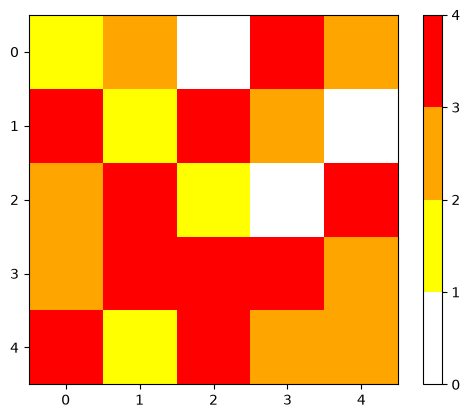

In [3]:
sandpiles.visualise_board(sandpile.board)

## Sandpile Topples

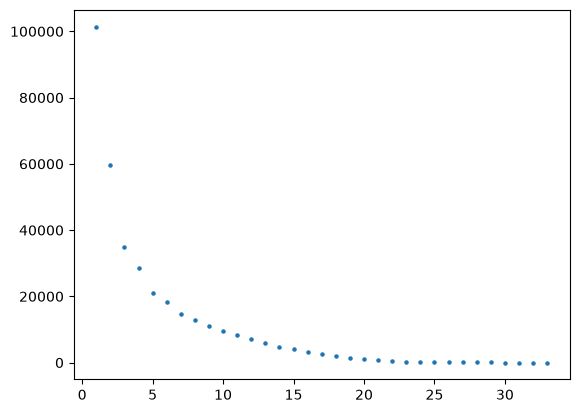

In [7]:
sandpiles.visualise_statistic(sandpile.topples, s=5)

In [21]:
from importlib import reload
import sandpiles
reload(sandpiles)
s = sandpiles.compute_powerlaw_MLEs(
    sandpile.topples
)
s

1.1279206323658526
-8.31311575291878 0.55795963927132 1.12722429192057


mpf('1.6229089820826285')

In [33]:
from importlib import reload
import sandpiles
reload(sandpiles)
s = sandpiles.compute_powerlaw_MLEs(
    sandpile.topples[sandpile.topples < np.exp(2)]
)
s

0.7710820370126579
-8.66995434827197 0.201121043918125 0.770385696567374


mpf('1.8176276942235587')

In [42]:
from importlib import reload
import sandpiles
reload(sandpiles)
sandpiles.compute_exp_trunc_pwr_mles(sandpile.topples[sandpile.topples > 0])

[2. 5.] -7360860.32477657
[2.00000001 5.        ] -7360860.33073785
[2.         5.00000001] -7360860.344315917
[1.70526974 4.03395959] -5976856.171736627
[1.70526976 4.03395959] -5976856.177684018
[1.70526974 4.0339596 ] -5976856.191255841
[0.5263487  0.16979795] -859093.7059103984
[0.52634872 0.16979795] -859093.7063874376
[0.5263487  0.16979796] -859093.7083062481


TypeError: float() argument must be a string or a real number, not 'mpc'

This looks like a power-law relationship.

Denote by $n_t(s)$ the number of topples of size $s$.

If $n_t(s) = \alpha s ^\beta$ then $\ln(n_t(s)) = \ln(\alpha) + s \ln (\beta)$.

Then, we can find $\ln (\alpha)$ and $\ln(\beta)$ via least-squares fit:

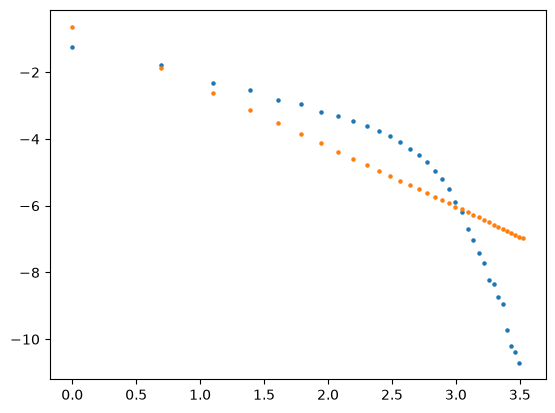

In [38]:
import mpmath

nonzero_topples = sandpile.topples[sandpile.topples > 0]
t_size, t_count = np.unique(nonzero_topples, return_counts = True)
log_t_size = np.log(t_size)
log_t_count = np.log(t_count / nonzero_topples.size)

plt.scatter(log_t_size, log_t_count, s=5)

s = 1.8
x = np.arange(1, 35)
logx = np.log(x)
logpdf = -np.log(float(mpmath.zeta(s, derivative=0))) - s*logx

plt.scatter(logx, logpdf, s=5)


c:\Users\purce\OneDrive\Documents\1- Graduate Studies\COMP90072 The Art of Scientific Computation\project\sandpiles.py:136: RuntimeWarning: divide by zero encountered in log
  stat = np.log(stat)


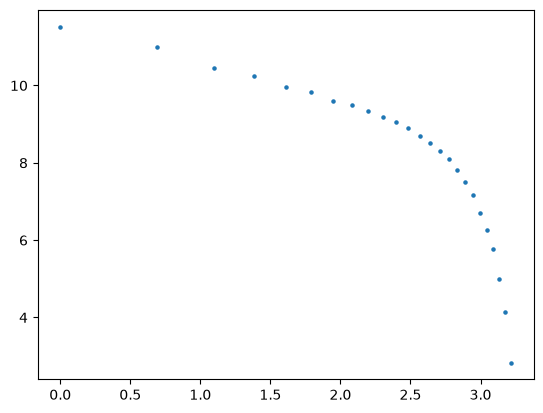

In [70]:
sandpiles.visualise_statistic(sandpile.area, log=True, s=5)